In [1]:
import sys
from pathlib import Path
import torch

sys.path.append(str(Path.cwd().parent))

In [2]:
from src.config import BASE_DIR, DATA_DIR
from src.data import get_dataloaders
from src.metrics import DepthLoss, draw_sample
from src.models import MonocularDepthModel
from src.pipeline import train_step, test_step

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
model = MonocularDepthModel(encoder_name="resnet34", pretrained=True)

train_csv = DATA_DIR / "nyu2_train.csv"
test_csv = DATA_DIR / "nyu2_test.csv"

train_loader, test_loader = get_dataloaders(BASE_DIR, train_csv, test_csv, 16)
images, depths = next(iter(train_loader))
pred_depths = model(images)

print(f"Output image batch: {images.shape}")
print(f"Output depth batch: {pred_depths.shape}")

assert pred_depths.shape == (16, 1, 384, 384), "Error! Shapes don't match"
print("Everything works just fine!")

Output image batch: torch.Size([16, 3, 384, 384])
Output depth batch: torch.Size([16, 1, 384, 384])
Everything works just fine!


In [5]:
model = model.to(device)

for param in model.encoder.parameters():
    param.requires_grad = True

decoder_params = (
    list(model.block5.parameters())
    + list(model.block4.parameters())
    + list(model.block3.parameters())
    + list(model.block2.parameters())
    + list(model.block1.parameters())
    + list(model.head.parameters())
)

optimizer = torch.optim.AdamW([
    {'params': model.encoder.parameters(), 'lr': 1e-5},
    {'params': decoder_params, 'lr': 1e-4}
], weight_decay=1e-2)
loss = DepthLoss(alpha=0.5)

In [6]:
import numpy as np
from PIL import Image

depth_sample_path = "../data/nyu2_test/01431_depth.png"

img = Image.open(depth_sample_path)
print(f"PIL Image Mode: {img.mode}")

depth_raw = np.array(img)
print(f"Raw DataType: {depth_raw.dtype}")
print(f"Raw Min value: {depth_raw.min()}")
print(f"Raw Max value: {depth_raw.max()}")

PIL Image Mode: I;16
Raw DataType: uint16
Raw Min value: 713
Raw Max value: 9908


In [7]:
X_tr, y_tr = next(iter(train_loader))
X_te, y_te = next(iter(test_loader))

print(f"TRAIN Target -> Min: {y_tr.min():.4f}, Max: {y_tr.max():.4f}")
print(f"TEST  Target -> Min: {y_te.min():.4f}, Max: {y_te.max():.4f}")

TRAIN Target -> Min: 0.0706, Max: 0.9882
TEST  Target -> Min: 0.0894, Max: 0.9961


In [8]:
epochs = 5
for i in range(epochs):
    train_step(model, train_loader, loss, optimizer, device)
    test_step(model, test_loader, loss, device)

Train Loss: 0.05037
Test Loss: 0.04523

Train Loss: 0.03462
Test Loss: 0.03951

Train Loss: 0.02931
Test Loss: 0.03835

Train Loss: 0.02613
Test Loss: 0.03669

Train Loss: 0.02408
Test Loss: 0.03539



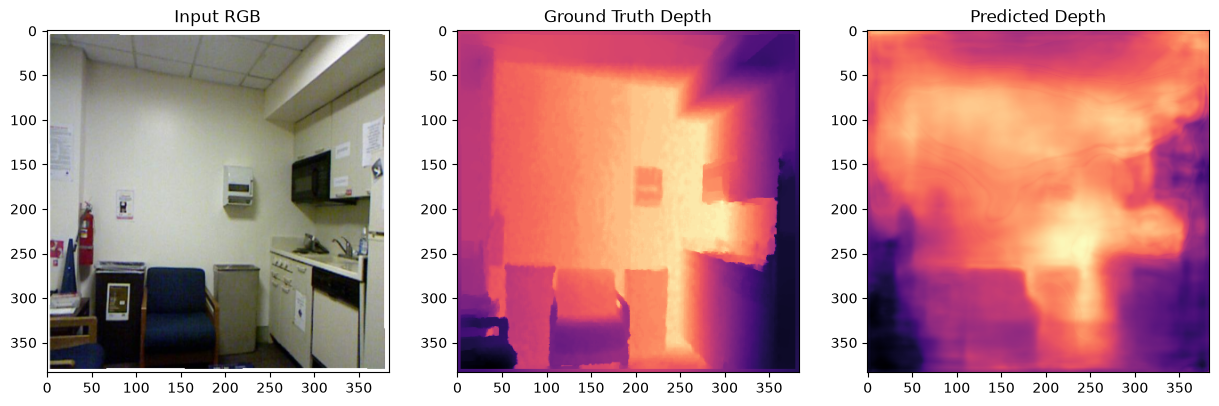

In [9]:
draw_sample(model, test_loader, device)

In [11]:
model.eval()

dummy_input = torch.randn(1, 3, 384, 384, device=device)

onnx_dir = Path("../models")
onnx_dir.mkdir(exist_ok=True)
onnx_path = onnx_dir / "unet_resnet34_depth_384.onnx"

torch.onnx.export(
    model, 
    dummy_input, 
    onnx_path, 
    export_params=True, 
    opset_version=14, 
    do_constant_folding=True, 
    input_names=["input_rgb"], 
    output_names=["output_depth"], 
    dynamic_axes={
        "input_rgb": {0: "batch_size"},
        "output_depth": {0: "batch_size"},
    },
)

print(f"Model has been succesfully exported in ONNX: {onnx_path}")

Model has been succesfully exported in ONNX: ../models/unet_resnet34_depth_384.onnx
